### Exploaratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
data = pd.read_csv(f'/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')
data_copy = data.copy()

data_copy.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [5]:
# Get number of rows and columns
print("Number of rows and columns:", data_copy.shape)

# Optional: Show number of rows and columns separately
print("Rows:", data_copy.shape[0])
print("Columns:", data_copy.shape[1])

Number of rows and columns: (10015, 7)
Rows: 10015
Columns: 7


In [6]:
# Separate columns by data type
char_cols = data_copy.select_dtypes(include='object')   # character/string columns
int_cols = data_copy.select_dtypes(include='number')    # numeric columns (int, float)

# Summary of character columns
print("Summary of character columns:")
print(char_cols.describe(include='all'))

print("\nSummary of numeric columns:")
print(int_cols.describe())

Summary of character columns:
          lesion_id      image_id     dx dx_type    sex localization
count         10015         10015  10015   10015  10015        10015
unique         7470         10015      7       4      3           15
top     HAM_0003789  ISIC_0027419     nv   histo   male         back
freq              6             1   6705    5340   5406         2192

Summary of numeric columns:
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


In [7]:
# Check total missing values per column
print("Missing values per column:")
print(data_copy.isnull().sum())

# Optional: Check percentage of missing values per column
print("\nPercentage of missing values per column:")
print((data_copy.isnull().sum() / len(data_copy)) * 100)

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Percentage of missing values per column:
lesion_id       0.000000
image_id        0.000000
dx              0.000000
dx_type         0.000000
age             0.569146
sex             0.000000
localization    0.000000
dtype: float64


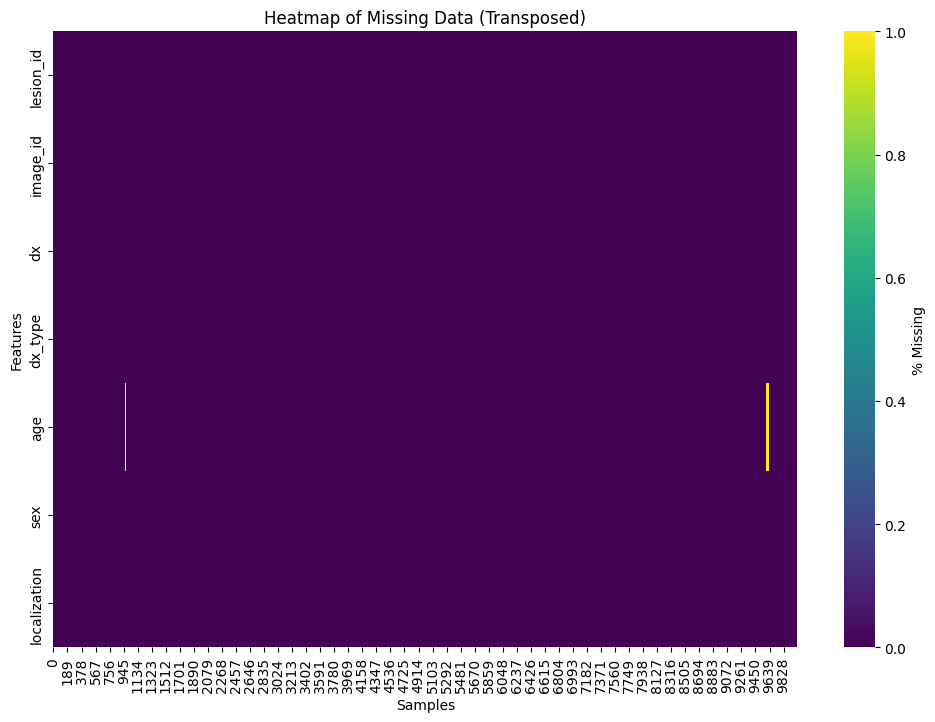

In [5]:
# Create boolean mask for missing values
missing = data_copy.isnull()

# Convert boolean to numeric (True=1, False=0)
missing_numeric = missing.astype(int)

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(missing_numeric.T, cmap="viridis", cbar_kws={'label': '% Missing'})
plt.title("Heatmap of Missing Data (Transposed)")
plt.xlabel("Samples")
plt.ylabel("Features")
plt.show()

In [6]:
# Count values in 'dx' column
lesion_counts = data_copy['dx'].value_counts()

# Print the counts
print("Lesion Type Counts:")
print(lesion_counts)

Lesion Type Counts:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


/var/folders/ng/y3jq4z5556l47rj1150jg7jm0000gn/T/ipykernel_12397/498162639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data_copy, x='dx', order=lesion_counts.index, palette='Set2')


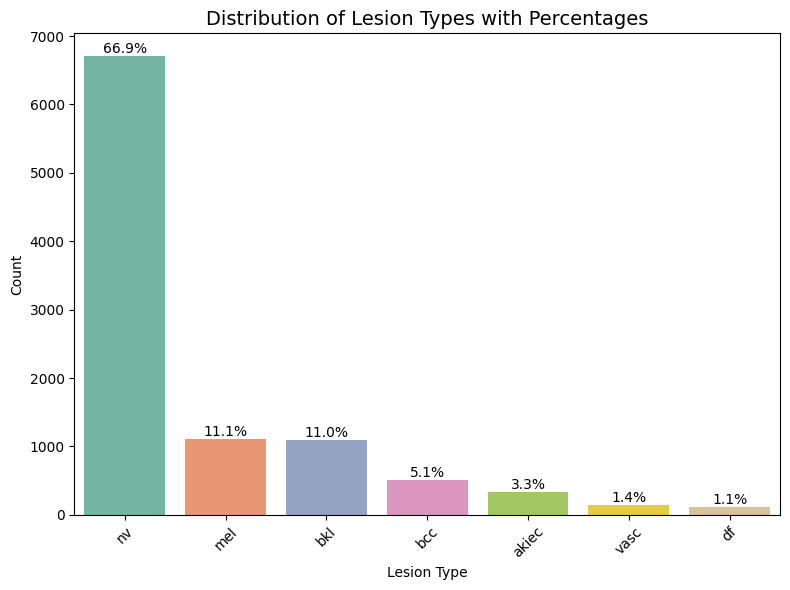

In [8]:
# Count lesion types
lesion_counts = data_copy['dx'].value_counts()
total = len(data_copy)

# Plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=data_copy, x='dx', order=lesion_counts.index, palette='Set2')

# Add percentage labels on top of bars
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., count), 
                ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Lesion Types with Percentages", fontsize=14)
plt.xlabel("Lesion Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/ng/y3jq4z5556l47rj1150jg7jm0000gn/T/ipykernel_15235/697792966.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data_copy, x='dx_type', order=lesion_counts.index, palette='Set2')


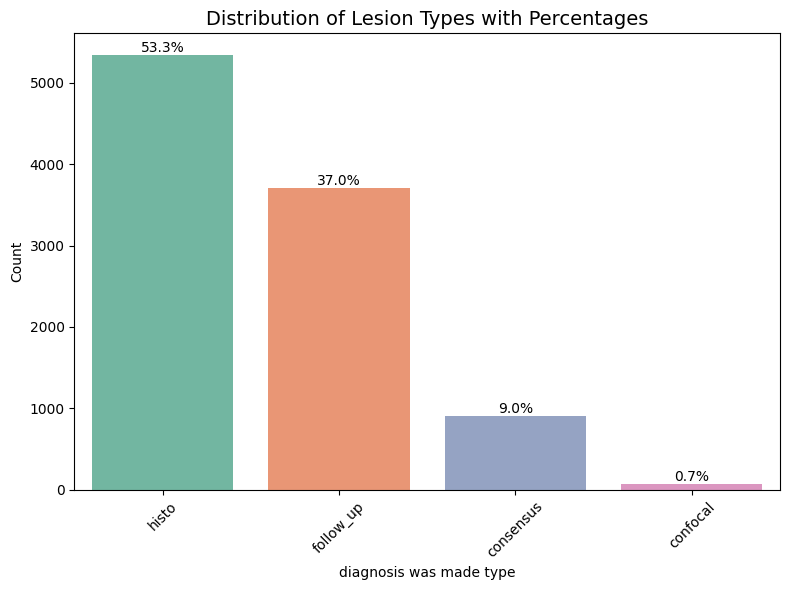

In [3]:
# Count lesion types
lesion_counts = data_copy['dx_type'].value_counts()
total = len(data_copy)

# Plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=data_copy, x='dx_type', order=lesion_counts.index, palette='Set2')

# Add percentage labels on top of bars
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., count), 
                ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Lesion Types with Percentages", fontsize=14)
plt.xlabel("diagnosis was made type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
data_copy.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


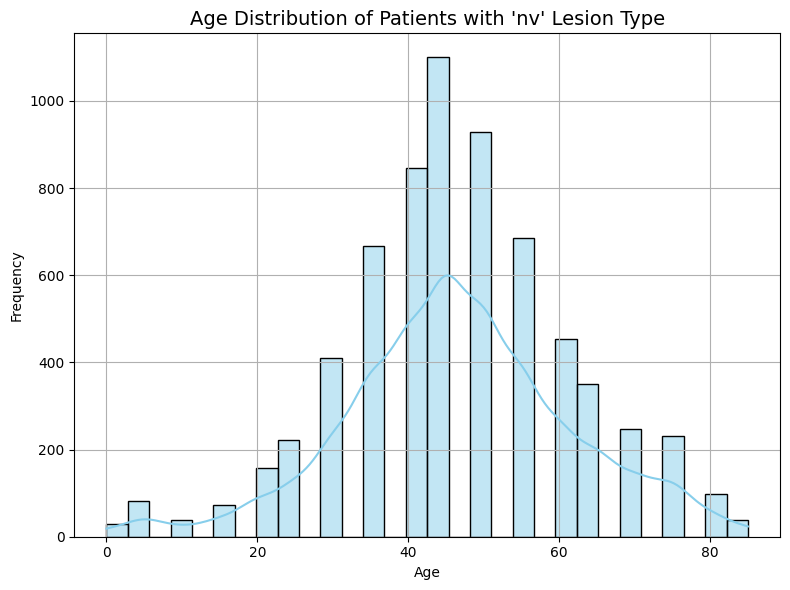

In [5]:
# Filter rows where dx == 'nv'
nv_df = data_copy[data_copy['dx'] == 'nv']

# Plot age distribution
plt.figure(figsize=(8, 6))
sns.histplot(nv_df['age'], bins=30, kde=True, color='skyblue')

plt.title("Age Distribution of Patients with 'nv' Lesion Type", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

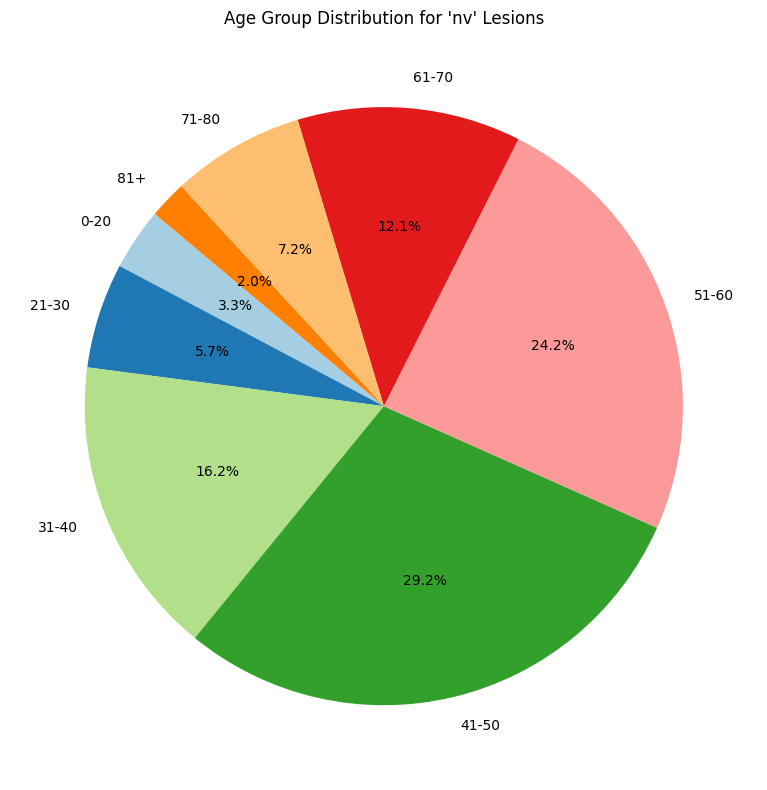

In [6]:
# Filter rows with 'nv' in dx column
nv_df = data_copy[data_copy['dx'] == 'nv']

# Drop missing age values
nv_df = nv_df.dropna(subset=['age'])

# Create age bins
bins = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81+']
nv_df['age_group'] = pd.cut(nv_df['age'], bins=bins, labels=labels, right=False)

# Count values in each age group
age_group_counts = nv_df['age_group'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(age_group_counts, labels=age_group_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Age Group Distribution for 'nv' Lesions")
plt.tight_layout()
plt.show()